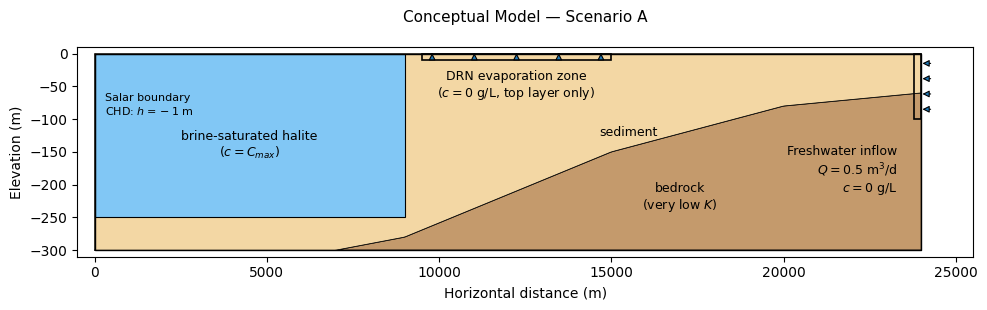

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -------------------------------------------------------
# Basic domain
# -------------------------------------------------------
L = 24000.0   # length (m)
D = 300.0     # depth (m)

# -------------------------------------------------------
# Bedrock top: starts ~7 km, never intersects halite (0 to -250 m)
# -------------------------------------------------------
def bedrock_top(x):
    x = np.asarray(x)
    z = np.empty_like(x, dtype=float)

    # 0–7000 m: deep bedrock at base
    mask = (x <= 7000.0)
    z[mask] = -300.0

    # 7000–9000 m: rises but stays below -250 m
    mask = (x > 7000.0) & (x <= 9000.0)
    z[mask] = -300.0 + (-280.0 + 300.0) * ((x[mask] - 7000.0) / (9000.0 - 7000.0))

    # 9000–15000 m
    mask = (x > 9000.0) & (x <= 15000.0)
    z[mask] = -280.0 + (-150.0 + 280.0) * ((x[mask] - 9000.0) / (15000.0 - 9000.0))

    # 15000–20000 m
    mask = (x > 15000.0) & (x <= 20000.0)
    z[mask] = -150.0 + (-80.0 + 150.0) * ((x[mask] - 15000.0) / (20000.0 - 15000.0))

    # 20000–24000 m
    mask = x > 20000.0
    z[mask] = -80.0 + (-60.0 + 80.0) * ((x[mask] - 20000.0) / (24000.0 - 20000.0))

    return z

xs = np.linspace(0, L, 400)
zs = bedrock_top(xs)

fig, ax = plt.subplots(figsize=(10, 3.2))

# -------------------------------------------------------
# Bedrock polygon
# -------------------------------------------------------
verts_bedrock = (
    [(0, -D), (0, bedrock_top(0.0))] +
    list(zip(xs, zs)) +
    [(L, -D)]
)
poly_bedrock = patches.Polygon(
    verts_bedrock, facecolor="#c49a6c", edgecolor="k", linewidth=0.8
)
ax.add_patch(poly_bedrock)

# -------------------------------------------------------
# Sediment polygon
# -------------------------------------------------------
verts_sed = (
    [(0, bedrock_top(0.0)), (0, 0), (L, 0), (L, bedrock_top(L))] +
    list(zip(xs[::-1], bedrock_top(xs[::-1])))
)
poly_sed = patches.Polygon(
    verts_sed, facecolor="#f3d7a4", edgecolor="k", linewidth=0.5
)
ax.add_patch(poly_sed)

# -------------------------------------------------------
# Halite / brine initial block: 0–9 km, 0 to –250 m
# -------------------------------------------------------
halite_width = 9000.0
halite_thickness = 250.0
halite_rect = patches.Rectangle(
    (0, -halite_thickness),
    halite_width,
    halite_thickness,
    facecolor="#81c7f5",
    edgecolor="k",
    linewidth=0.8,
)
ax.add_patch(halite_rect)

# -------------------------------------------------------
# DRN evaporation zone: 9.5–15 km, top ~10 m
# -------------------------------------------------------
drn_start = 9500.0
drn_end = 15000.0
drn_thickness = 10.0

# band at the surface
drn_rect = patches.Rectangle(
    (drn_start, -drn_thickness),
    drn_end - drn_start,
    drn_thickness,
    facecolor="none",
    edgecolor="k",
    linewidth=1.2,
)
ax.add_patch(drn_rect)

# arrows ON TOP, pointing upward
for x_arrow in np.linspace(drn_start + 300, drn_end - 300, 5):
    ax.annotate(
        "",
        xy=(x_arrow, 5),      # head above surface
        xytext=(x_arrow, -5), # tail just below
        arrowprops=dict(arrowstyle="-|>", linewidth=0.8),
    )

# -------------------------------------------------------
# Freshwater inflow: vertical strip at 24 km, upper 100 m
# -------------------------------------------------------
inflow_depth = 100.0
inflow_width = 200.0

inflow_rect = patches.Rectangle(
    (L - inflow_width, -inflow_depth),
    inflow_width,
    inflow_depth,
    facecolor="none",
    edgecolor="k",
    linewidth=1.2,
)
ax.add_patch(inflow_rect)

# arrows pointing INTO the domain
for y_arrow in np.linspace(-15, -85, 4):
    ax.annotate(
        "",
        xy=(L - 50, y_arrow),    # head just inside
        xytext=(L + 350, y_arrow),  # tail outside
        arrowprops=dict(arrowstyle="-|>", linewidth=0.8),
    )

# -------------------------------------------------------
# Domain outline
# -------------------------------------------------------
ax.plot([0, L, L, 0, 0], [0, 0, -D, -D, 0], "k", linewidth=1.0)

# -------------------------------------------------------
# Axis limits and labels
# -------------------------------------------------------
ax.set_xlim(-500, L + 1500)
ax.set_ylim(-D - 10, 10)
ax.set_xlabel("Horizontal distance (m)", fontsize=10)
ax.set_ylabel("Elevation (m)", fontsize=10)

fs_main = 9

# -------------------------------------------------------
# Text labels
# -------------------------------------------------------

# Salar boundary + CHD/CNC
ax.text(
    300, -60,
    "Salar boundary\n"
    "CHD: $h = -1$ m\n",
    ha="left", va="top", fontsize=8,
)

# Brine block
ax.text(
    4500, -140,
    "brine-saturated halite\n($c = C_{max}$)",
    ha="center", va="center", fontsize=fs_main,
)

# Sediment label
ax.text(
    15500,     # shift right
    -120,      # move down
    "sediment",
    ha="center",
    va="center",
    fontsize=fs_main,
)


# Bedrock
ax.text(
    17000, -220,
    "bedrock\n(very low $K$)",
    ha="center", va="center", fontsize=fs_main,
)

# DRN label – inside figure, below arrows
ax.text(
    (drn_start + drn_end) / 2.0,
    -25,
    "DRN evaporation zone\n($c = 0$ g/L, top layer only)",
    ha="center", va="top", fontsize=fs_main,
)

# Freshwater inflow label
ax.text(
    L - 700, -140,
    "Freshwater inflow\n"
    "$Q = 0.5$ m$^3$/d\n"
    "$c = 0$ g/L",
    ha="right", va="top", fontsize=fs_main,
)

# (optional) no-flow bottom text – uncomment if you want it
# ax.text(
#     L / 2.0, -D + 12,
#     "no-flow bottom",
#     ha="center", va="center", fontsize=8,
# )

ax.set_title("Conceptual Model — Scenario A", fontsize=11, pad=18)

plt.tight_layout()
# plt.savefig("conceptual_model_scenarioA_final.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import flopy.utils as fu
from pathlib import Path
import pandas as pd
# Grid dimensions (match your MF6 model)
nlay = 30
nrow = 1
ncol = 240

delr = 100.0  # m
delc = 1.0    # m
delv = 10.0   # m
porosity_const = 0.30


root = Path.cwd() / "CS_A1"
het = root / "Scenario_A"
homo = root / "Scenario_A_homo"


In [10]:
def load_last_heads(model_ws):
    hf = fu.HeadFile(str(model_ws / "flow.hds"))
    t = hf.get_times()[-1]
    return t, hf.get_data(totim=t)

from pathlib import Path
import flopy.utils as fu
import numpy as np

def load_last_conc(model_ws):
    """
    Robust reader for the last-time concentration array.

    Tries:
      - UcnFile (double / single precision)
      - HeadFile with text='CONCENTRATION' (double / single)
    """
    path = Path(model_ws) / "trans.ucn"
    if (not path.exists()) or (path.stat().st_size < 512):
        raise FileNotFoundError(f"trans.ucn not found or too small in {model_ws}")

    tries = [
        (fu.UcnFile,  {"precision": "double"}),
        (fu.UcnFile,  {"precision": "single"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "double"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "single"}),
    ]

    last_err = None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times:
                continue
            t = float(times[-1])
            arr = fh.get_data(totim=t)
            return t, arr
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Could not read concentration from {path.name}: {last_err}")

def load_spdis(model_ws):
    """
    Load qx, qz from DATA-SPDIS for the last time step.
    Assumes nrow = 1 and uses known nlay, ncol from the model.
    """
    model_ws = Path(model_ws)
    cbb = fu.CellBudgetFile(str(model_ws / "flow.bud"), precision="double")
    t = cbb.get_times()[-1]

    # Try DATA-SPDIS first
    sp = cbb.get_data(text="DATA-SPDIS", totim=t)
    if sp:
        rec = sp[0]
        flat_qx = rec["qx"]    # length = nlay*nrow*ncol
        flat_qz = rec["qz"]
        # reshape to (nlay, nrow, ncol) then squeeze row
        qx = flat_qx.reshape(nlay, nrow, ncol)[:, 0, :]
        qz = flat_qz.reshape(nlay, nrow, ncol)[:, 0, :]
        return qx, qz

    # Fallback: derive from face flows
    qxr = cbb.get_data(text="FLOW RIGHT FACE", totim=t)[0][:, 0, :]  # shape (nlay, ncol+1)
    qzl = cbb.get_data(text="FLOW LOWER FACE", totim=t)[0][:, 0, :]  # shape (nlay+1, ncol)

    # Cell-centered approximations
    qx = 0.5 * (qxr[:, :-1] + qxr[:, 1:])    # (nlay, ncol)
    qz = 0.5 * (qzl[:-1, :] + qzl[1:, :])    # (nlay, ncol)

    return qx, qz


In [11]:
t_het, H_het = load_last_heads(het)
t_homo, H_homo = load_last_heads(homo)

t_hetC, C_het = load_last_conc(het)
t_homoC, C_homo = load_last_conc(homo)

qx_h, qz_h = load_spdis(het)
qx_m, qz_m = load_spdis(homo)


C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(


In [12]:
def bottom_toe(C3d, delr, threshold=5.0):
    """Toe from bottom layer only."""
    Cbot = C3d[-1,0,:]
    cols = np.where(Cbot > threshold)[0]
    if len(cols) == 0:
        return np.nan
    return cols[-1] * delr


In [13]:
def true_toe(C3d, delr, threshold=5.0):
    """
    “True” toe = farthest inland column where 
    ANY layer still has concentration > threshold.
    """
    Cmax_col = np.nanmax(C3d[:,0,:], axis=0)
    cols = np.where(Cmax_col > threshold)[0]
    if len(cols) == 0:
        return np.nan
    return cols[-1] * delr


In [14]:
toe_homo = bottom_toe(C_homo, delr=100.0)
toe_het  = bottom_toe(C_het,  delr=100.0)

toe_true_homo = true_toe(C_homo, delr=100.0)
toe_true_het  = true_toe(C_het,  delr=100.0)


In [15]:
def get_max_upward(qz):
    return np.min(qz)  # most negative = strongest upward flow

max_up_homo = get_max_upward(qz_m)
max_up_het  = get_max_upward(qz_h)

max_up_homo, max_up_het


(np.float64(-0.4725676407721856), np.float64(-0.8896230712275479))

In [16]:
def get_salt_mass(C):
    # mass per cell = concentration * volume * porosity
    vol = delr * delc * delv
    cell_mass = C * porosity_const * vol
    return cell_mass.sum()

mass_homo = get_salt_mass(C_homo)
mass_het  = get_salt_mass(C_het)

mass_homo, mass_het


(np.float64(283964597.55921066), np.float64(287977142.72425723))

In [17]:
summary = {
    "Bottom toe (m)": [toe_homo, toe_het],
    "True toe (m)": [toe_true_homo, toe_true_het],
    "Max upward qz (m/d)": [max_up_homo, max_up_het],
    "Salt mass (kg)": [mass_homo, mass_het],
}

df = pd.DataFrame(summary, index=["Homo", "Hetero"])
df


,Bottom toe (m),True toe (m),Max upward qz (m/d),Salt mass (kg)
Homo,12600.0,16100.0,-0.472568,2.839646e+08
Hetero,12600.0,17600.0,-0.889623,2.879771e+08


In [18]:
from pathlib import Path
import numpy as np
import flopy
import flopy.utils as fu
import matplotlib.pyplot as plt

# --- paths to your two runs ---
root = Path.cwd() / "CS_A1"
het = root / "Scenario_A"        # heterogeneous
homo = root / "Scenario_A_homo"  # homogeneous

# --- load MF6 simulations from disk ---
sim_het = flopy.mf6.MFSimulation.load(sim_ws=het)
sim_homo = flopy.mf6.MFSimulation.load(sim_ws=homo)

# --- use the homogeneous flow model to get grid info (both use same grid) ---
gwf = sim_homo.get_model("flow")
dis = gwf.get_package("dis")

delr = dis.delr.array          # length ncol (e.g., 240)
x_edges = np.concatenate(([0.0], np.cumsum(delr)))  # cell edges in meters
xmin, xmax = float(x_edges[0]), float(x_edges[-1])

top = float(dis.top.array[0, 0])
zbot = float(dis.botm.array[-1, 0, 0])

print("x range (m):", xmin, "→", xmax)
print("z range (m):", zbot, "→", top)


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package chd...
    loading package drn...
    loading package wel...
    loading package buy...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package mst...
    loading package adv...
    loading package dsp...
    loading package cnc...
    loading package ssm...
    loading package oc...
  loading exchange package gwf-gwt_exg_0...
  loading solution package flow...
  loading solution package trans...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package chd...
    loading package drn...
    loading package wel...
    lo

C:\Users\isabe\AppData\Local\Temp\ipykernel_21808\1532023260.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


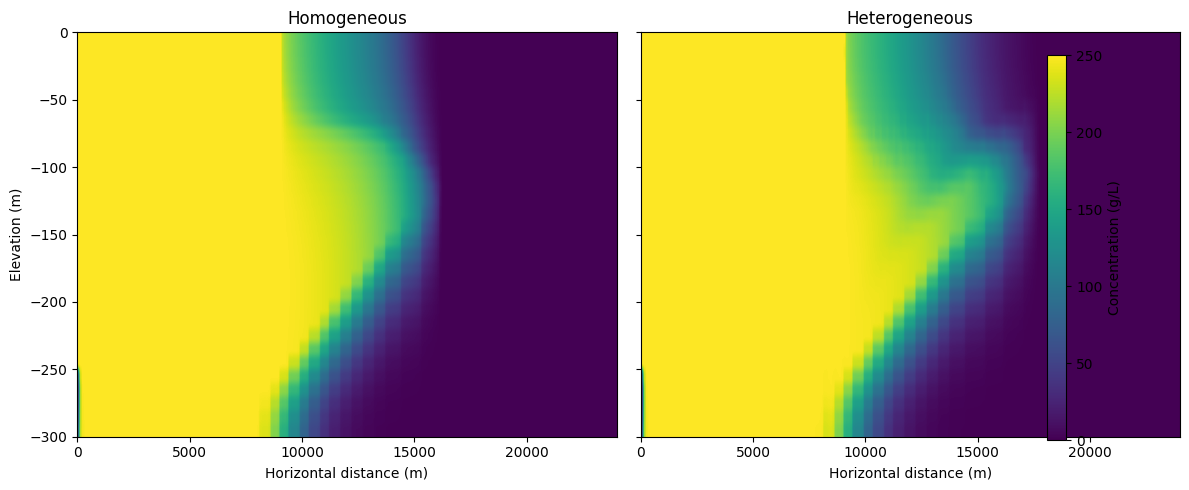

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- assume C_homo and C_het are already loaded as (nlay, 1, ncol) arrays ---

# Extract 2D slices (layer, col)
C_homo_2d = C_homo[:, 0, :]   # shape (nlay, ncol)
C_het_2d  = C_het[:, 0, :]    # shape (nlay, ncol)

# Flip vertically so top layer is at the top of the plot
C_homo_plot = np.flipud(C_homo_2d)
C_het_plot  = np.flipud(C_het_2d)

# Spatial extents (consistent with your model):
xmin, xmax = 0.0, 24000.0   # m
zmin, zmax = -300.0, 0.0    # m

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ----- Homogeneous -----
im0 = ax[0].imshow(
    C_homo_plot,
    origin="lower",
    extent=[xmin, xmax, zmin, zmax],
    vmin=0.0,
    vmax=250.0,
    cmap="viridis",
    aspect="auto",
)
ax[0].set_title("Homogeneous")
ax[0].set_xlabel("Horizontal distance (m)")
ax[0].set_ylabel("Elevation (m)")

# ----- Heterogeneous -----
im1 = ax[1].imshow(
    C_het_plot,
    origin="lower",
    extent=[xmin, xmax, zmin, zmax],
    vmin=0.0,
    vmax=250.0,
    cmap="viridis",
    aspect="auto",
)
ax[1].set_title("Heterogeneous")
ax[1].set_xlabel("Horizontal distance (m)")

# ----- Shared colorbar -----
cbar = fig.colorbar(im1, ax=ax.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("Concentration (g/L)")

plt.tight_layout()
plt.show()


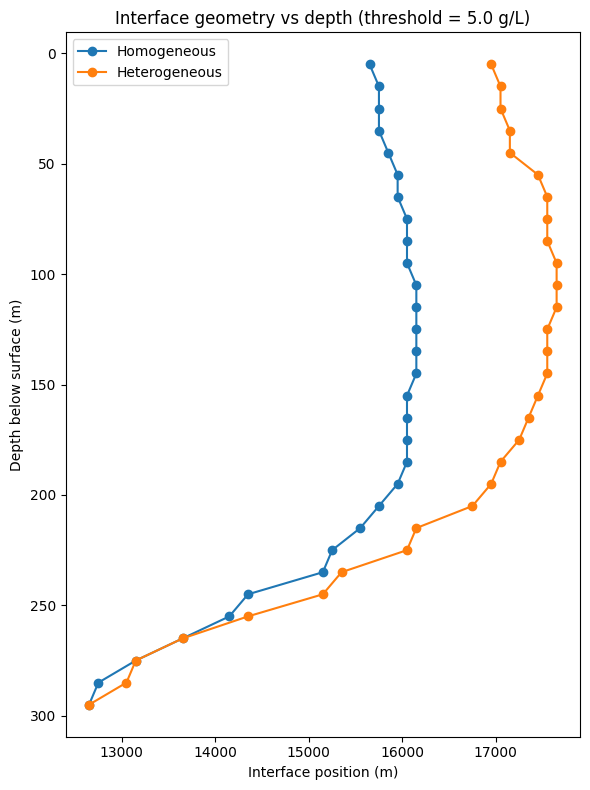

In [20]:
# Block 11 (replace your old interface_profile block with this)

import numpy as np
import matplotlib.pyplot as plt

interface_threshold = 5.0  # g/L, same as your toe definition

def interface_profile(C3d, threshold=5.0, delr_cell=100.0, delv_cell=10.0):
    """
    For each layer, find the furthest inland column where concentration > threshold.
    Uses constant cell size delr_cell (m) and delv_cell (m).
    Returns:
      depths  : 1D array of depth (m) for each layer center
      x_iface : 1D array of x-position (m) of the interface for each layer
    """
    nlay, nrow, ncol = C3d.shape
    depths = (np.arange(nlay) + 0.5) * delv_cell  # depth to layer centers
    x_iface = np.full(nlay, np.nan)

    for k in range(nlay):
        prof = C3d[k, 0, :]  # single row
        cols = np.where(prof > threshold)[0]
        if cols.size > 0:
            j_toe = cols[-1]  # furthest inland column above threshold
            x_iface[k] = (j_toe + 0.5) * delr_cell  # cell center in meters

    return depths, x_iface

# Get profiles for both models
depth_homo, xint_homo = interface_profile(C_homo, threshold=interface_threshold)
depth_het,  xint_het  = interface_profile(C_het,  threshold=interface_threshold)

# Plot
plt.figure(figsize=(6, 8))
plt.plot(xint_homo, depth_homo, marker="o", label="Homogeneous")
plt.plot(xint_het,  depth_het,  marker="o", label="Heterogeneous")

plt.gca().invert_yaxis()  # depth increases downward visually
plt.xlabel("Interface position (m)")
plt.ylabel("Depth below surface (m)")
plt.title(f"Interface geometry vs depth (threshold = {interface_threshold} g/L)")
plt.legend()
plt.tight_layout()
plt.show()


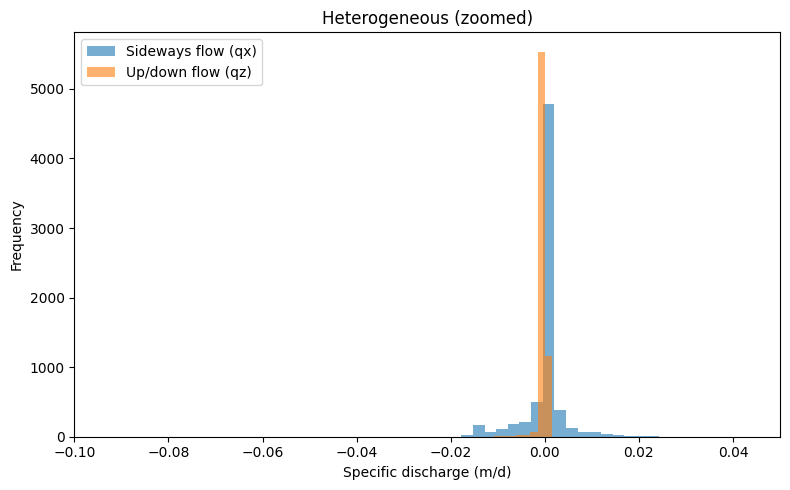

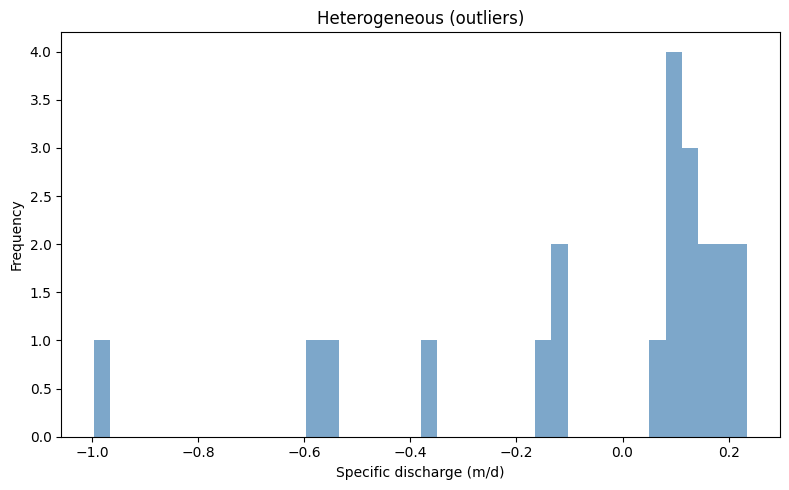

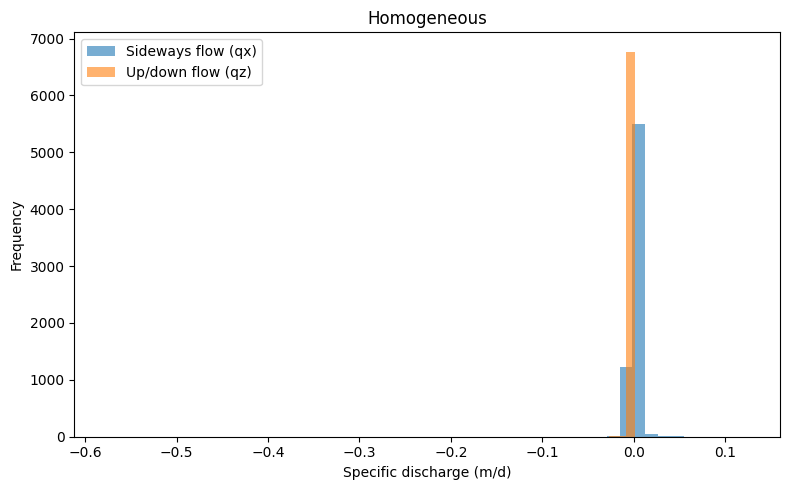

In [21]:
# Block 12: Histograms of qx vs qz for each simulation
import numpy as np
import matplotlib.pyplot as plt

def prep_q(qx, qz, tol=1e-12):
    """
    Flatten qx, qz and remove tiny values (near zero).
    Returns:
        qx_flat, qz_flat as 1D arrays.
    """
    qx_flat = qx.flatten()
    qz_flat = qz.flatten()
    mask = (np.abs(qx_flat) > tol) | (np.abs(qz_flat) > tol)
    return qx_flat[mask], qz_flat[mask]

# Prepare flattened arrays
qx_h_flat, qz_h_flat = prep_q(qx_h, qz_h)   # heterogeneous
qx_m_flat, qz_m_flat = prep_q(qx_m, qz_m)   # homogeneous


# -------------------------------------------------------------------------
# (A) Heterogeneous model — ZOOMED histogram (main distribution)
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))

# Zoom into the meaningful range
zoom_min, zoom_max = -0.1, 0.05      

plt.hist(qx_h_flat[(qx_h_flat > zoom_min) & (qx_h_flat < zoom_max)],
         bins=60, alpha=0.6, label="Sideways flow (qx)")
plt.hist(qz_h_flat[(qz_h_flat > zoom_min) & (qz_h_flat < zoom_max)],
         bins=60, alpha=0.6, label="Up/down flow (qz)")

plt.xlabel("Specific discharge (m/d)")
plt.ylabel("Frequency")
plt.title("Heterogeneous (zoomed)")
plt.legend(loc="upper left")
plt.xlim(zoom_min, zoom_max)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# (B) Heterogeneous model — OUTLIERS only (fast-flow channels)
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))

outlier_mask = (qx_h_flat <= zoom_min) | (qx_h_flat >= zoom_max)
plt.hist(qx_h_flat[outlier_mask], bins=40, alpha=0.7, color="steelblue")

plt.xlabel("Specific discharge (m/d)")
plt.ylabel("Frequency")
plt.title("Heterogeneous (outliers)")
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# (C) Homogeneous model — simple histogram
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(qx_m_flat, bins=50, alpha=0.6, label="Sideways flow (qx)")
plt.hist(qz_m_flat, bins=50, alpha=0.6, label="Up/down flow (qz)")

plt.xlabel("Specific discharge (m/d)")
plt.ylabel("Frequency")
plt.title("Homogeneous")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


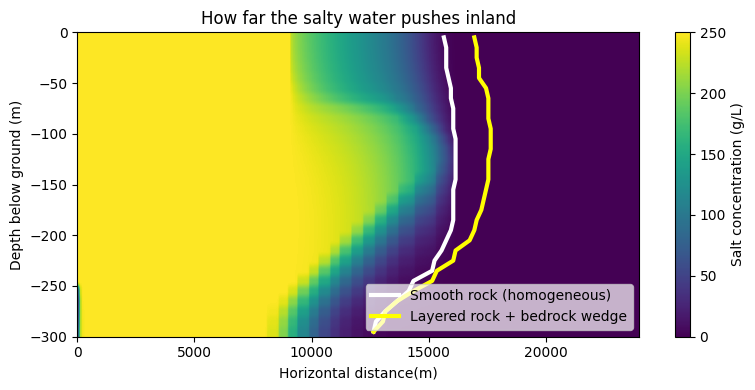

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Use your homogeneous concentration field as the background
# (you can also do this for hetero or make a 2-panel figure)
fig, ax = plt.subplots(figsize=(8, 4))

# background salinity (homogeneous for example)
im = ax.imshow(
    np.flipud(C_homo_2d),           # flip so surface is at top
    origin="lower",
    extent=[xmin, xmax, zmin, zmax],
    vmin=0.0,
    vmax=250.0,
    aspect="auto",
)

# overlay interface curves (convert depth indices to z if you want)
# here we just treat 'depth' as positive downward and shift sign
z_homo = -depth_homo    # make depths negative so 0 is surface
z_het  = -depth_het

ax.plot(xint_homo, z_homo, color="white", lw=3, label="Smooth rock (homogeneous)")
ax.plot(xint_het,  z_het,  color="yellow", lw=3, label="Layered rock + bedrock wedge")

ax.set_xlabel("Horizontal distance(m)")
ax.set_ylabel("Depth below ground (m)")
ax.set_title("How far the salty water pushes inland")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Salt concentration (g/L)")

ax.legend(loc="lower right", framealpha=0.7)

plt.tight_layout()
plt.show()


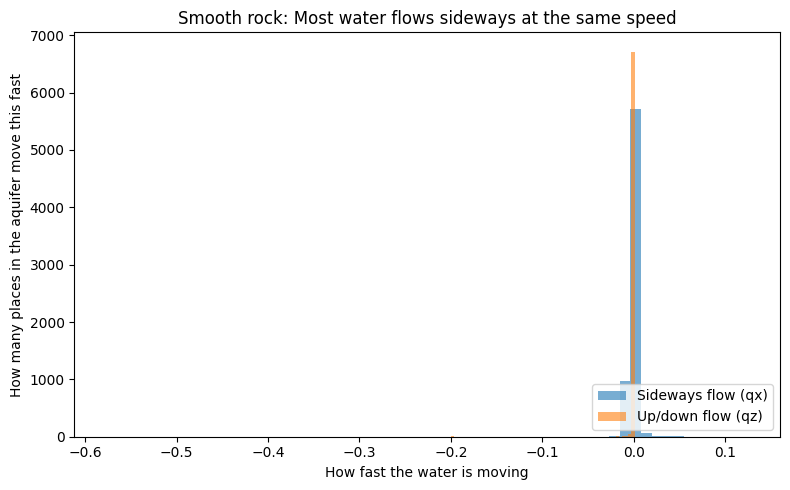

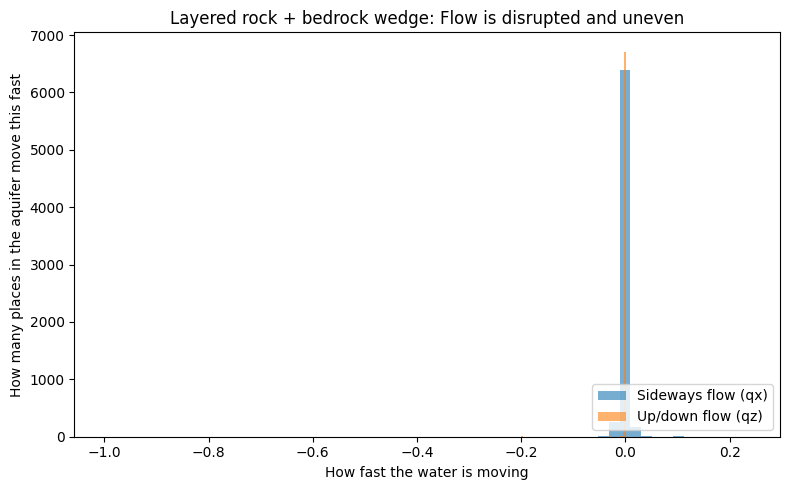

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def normal_person_hist(qx, qz, title):
    plt.figure(figsize=(8, 5))

    # Simplify by clipping extreme values so the plot doesn't look wild
    qx_clip = np.clip(qx, -2, 2)
    qz_clip = np.clip(qz, -0.2, 0.2)

    plt.hist(qx_clip, bins=60, alpha=0.6, label="Sideways flow (qx)")
    plt.hist(qz_clip, bins=60, alpha=0.6, label="Up/down flow (qz)")

    plt.xlabel("How fast the water is moving")
    plt.ylabel("How many places in the aquifer move this fast")
    plt.title(title)

    plt.legend(loc="lower right", framealpha=0.8)
    plt.tight_layout()
    plt.show()


# Run them
normal_person_hist(qx_m_flat, qz_m_flat,
                   "Smooth rock: Most water flows sideways at the same speed")

normal_person_hist(qx_h_flat, qz_h_flat,
                   "Layered rock + bedrock wedge: Flow is disrupted and uneven")


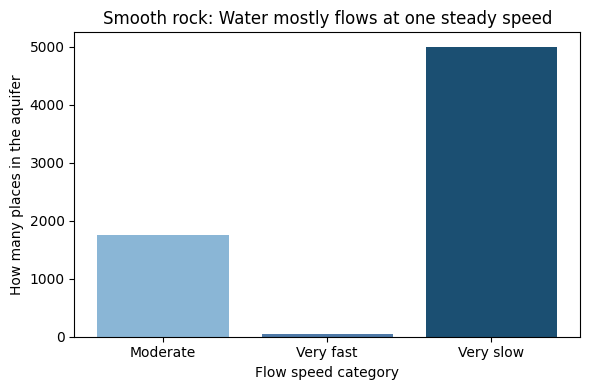

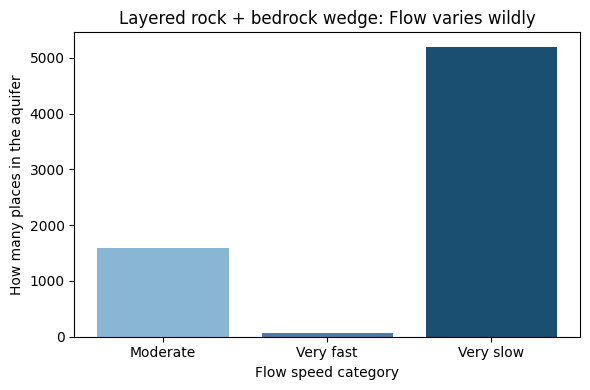

In [24]:
def classify_flow(q):
    q = np.abs(q)  # speed only (no negative sign)
    return np.where(q < 0.002, "Very slow",
           np.where(q < 0.02,  "Moderate",
                               "Very fast"))

def flow_bar_chart(qx, title):
    labels, counts = np.unique(classify_flow(qx), return_counts=True)

    plt.figure(figsize=(6,4))
    plt.bar(labels, counts, color=["#8ab6d6", "#4e79a7", "#1b4f72"])
    plt.title(title)
    plt.ylabel("How many places in the aquifer")
    plt.xlabel("Flow speed category")
    plt.tight_layout()
    plt.show()

flow_bar_chart(qx_m_flat, 
    "Smooth rock: Water mostly flows at one steady speed")

flow_bar_chart(qx_h_flat, 
    "Layered rock + bedrock wedge: Flow varies wildly")
